#  Master Lab Fraud Detection Benchmark
## Hybrid Stacking vs Standalone Algorithmic Paradigms

**Note to User:** This notebook is designed to be self-contained. It will check for dependencies and data files automatically before execution.

###  Scientific Question:
Does the fusion of structural diversity (Boosting + Bagging) and Bayesian calibration significantly outperform individual state-of-the-art models?

In [1]:
# [0] Dependency Auto-Resolution
import sys
import subprocess

def install_missing(packages):
    for pkg in packages:
        try:
            __import__(pkg.replace('-', '_'))
        except ImportError:
            print(f"[*] Installing missing dependency: {pkg}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

install_missing(['pandas', 'numpy', 'matplotlib', 'seaborn', 'joblib', 'xgboost', 'imbalanced-learn', 'category-encoders', 'scikit-learn'])
print("[OK] All dependencies verified.")

[*] Installing missing dependency: imbalanced-learn...
[*] Installing missing dependency: scikit-learn...
[OK] All dependencies verified.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import BayesianRidge, LogisticRegression
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from category_encoders import TargetEncoder
from sklearn.metrics import average_precision_score, precision_recall_curve

# [1] Path Sanitization Logic
current_dir = os.getcwd()
data_candidates = [
    os.path.join(current_dir, "data/fraudTrain.csv"),
    os.path.join(current_dir, "../data/fraudTrain.csv"),
    os.path.join(current_dir, "fraudTrain.csv")
]

DATA_PATH = next((p for p in data_candidates if os.path.exists(p)), None)

if not DATA_PATH:
    print("[ERROR] Data file not found! Please ensure 'fraudTrain.csv' is in a 'data/' folder.")
else:
    print(f"[OK] Data found at: {DATA_PATH}")

MODEL_DIR = os.path.join(current_dir, "../app/models/")
os.makedirs(MODEL_DIR, exist_ok=True)

[OK] Data found at: c:\Users\REGI GROUP\Documents\Fraud_Detection\research\../data/fraudTrain.csv


In [4]:
print("[*] Ingesting forensic data stream...")
df_raw = pd.read_csv(DATA_PATH, nrows=50000) 
print(f"[OK] Dataset loaded: {df_raw.shape[0]} samples, {df_raw.shape[1]} features.")

[*] Ingesting forensic data stream...
[OK] Dataset loaded: 50000 samples, 23 features.


## 1.  Forensic Exploratory Data Analysis (EDA)
An expert-level audit of the distribution, imbalance, and correlation vectors.

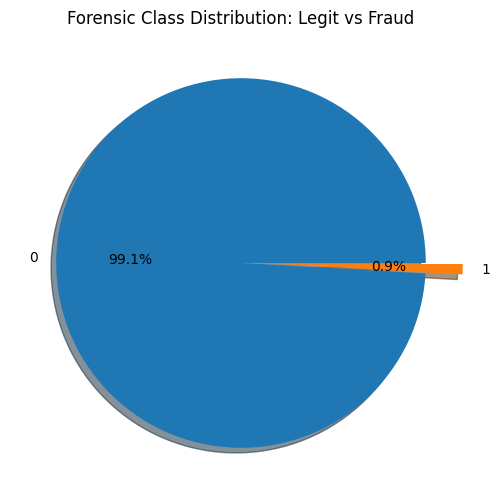

--- Descriptive Statistics (Numerical Core) ---
                amt      city_pop           lat          long     unix_time
count  50000.000000  5.000000e+04  50000.000000  50000.000000  5.000000e+04
mean      71.595958  8.934445e+04     38.531815    -90.180867  1.326652e+09
std      149.237615  3.006253e+05      5.095027     13.910532  7.320915e+05
min        1.000000  2.300000e+01     20.027100   -165.672300  1.325376e+09
25%        9.740000  7.430000e+02     34.668900    -96.790900  1.325999e+09
50%       47.870000  2.456000e+03     39.371600    -87.366700  1.326627e+09
75%       83.610000  2.112500e+04     41.846700    -80.065200  1.327251e+09
max    11872.210000  2.906700e+06     65.689900    -67.950300  1.327877e+09


In [5]:
# [EDA] Class Imbalance Audit
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e']
df_raw['is_fraud'].value_counts().plot.pie(autopct='%1.1f%%', colors=colors, explode=(0, 0.2), shadow=True)
plt.title("Forensic Class Distribution: Legit vs Fraud")
plt.ylabel("")
plt.show()

print("--- Descriptive Statistics (Numerical Core) ---")
print(df_raw[['amt', 'city_pop', 'lat', 'long', 'unix_time']].describe())

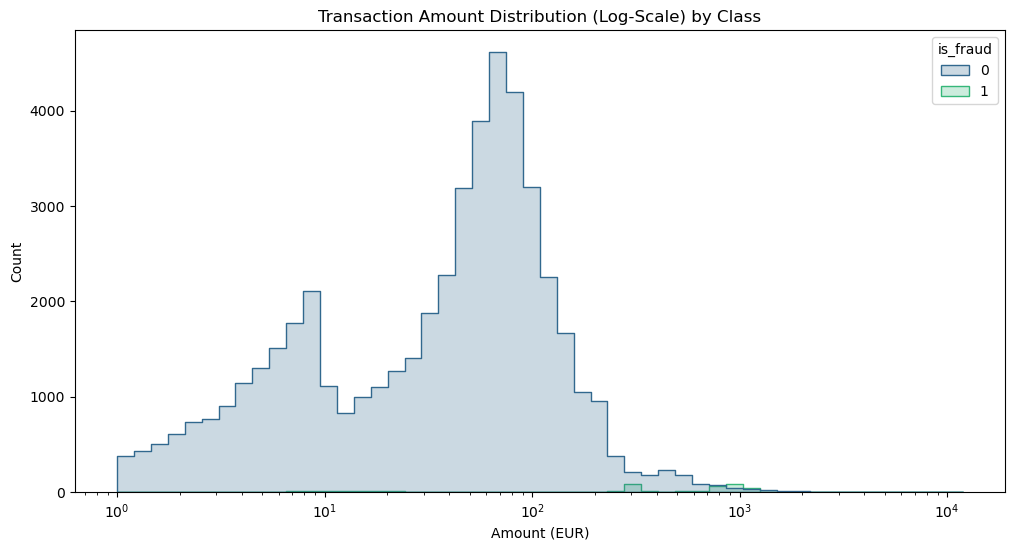

In [4]:
# [EDA] Univariate Analysis: Transaction Amount (amt)
plt.figure(figsize=(12, 6))
sns.histplot(data=df_raw, x='amt', hue='is_fraud', bins=50, log_scale=True, palette='viridis', element='step')
plt.title("Transaction Amount Distribution (Log-Scale) by Class")
plt.xlabel("Amount (EUR)")
plt.show()

C:\Users\REGI GROUP\AppData\Local\Temp\ipykernel_11636\2413136272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw[df_raw['is_fraud']==1], y='category', order=df_raw['category'].value_counts().index, palette='magma')


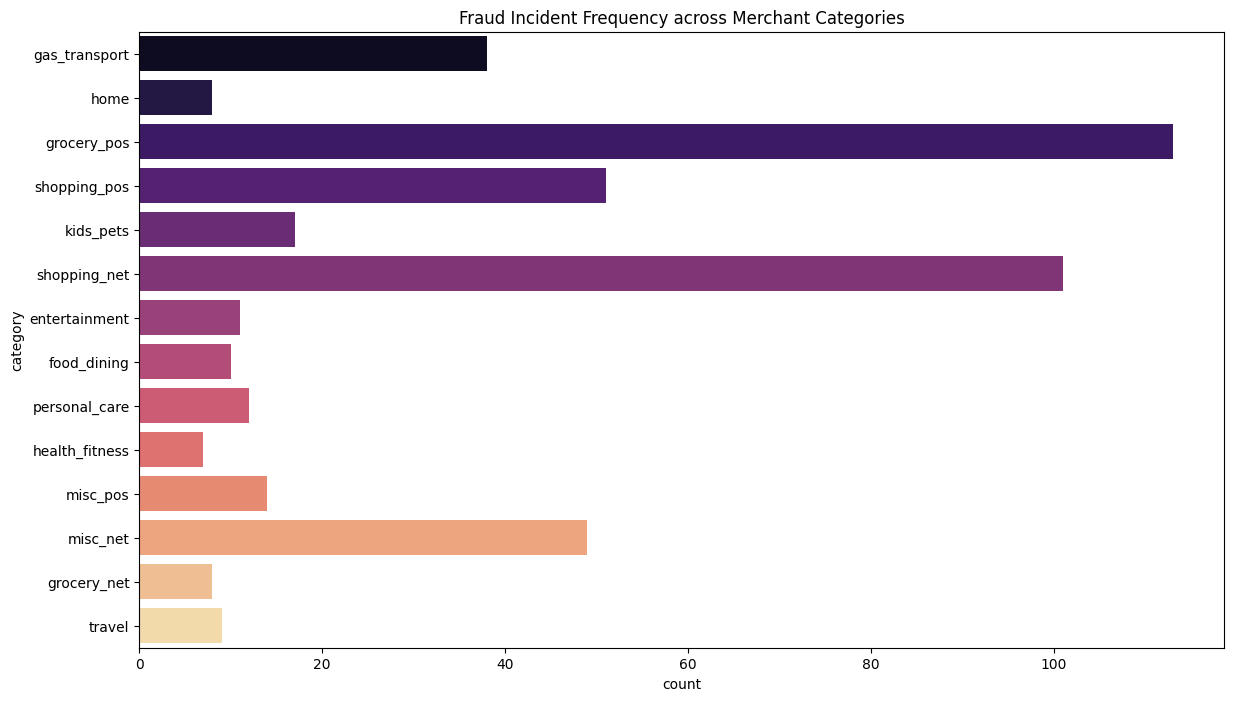

In [7]:
# [EDA] Categorical Insight: Fraud Frequency by Category
plt.figure(figsize=(14, 8))
sns.countplot(data=df_raw[df_raw['is_fraud']==1], y='category', order=df_raw['category'].value_counts().index, palette='magma')
plt.title("Fraud Incident Frequency across Merchant Categories")
plt.show()

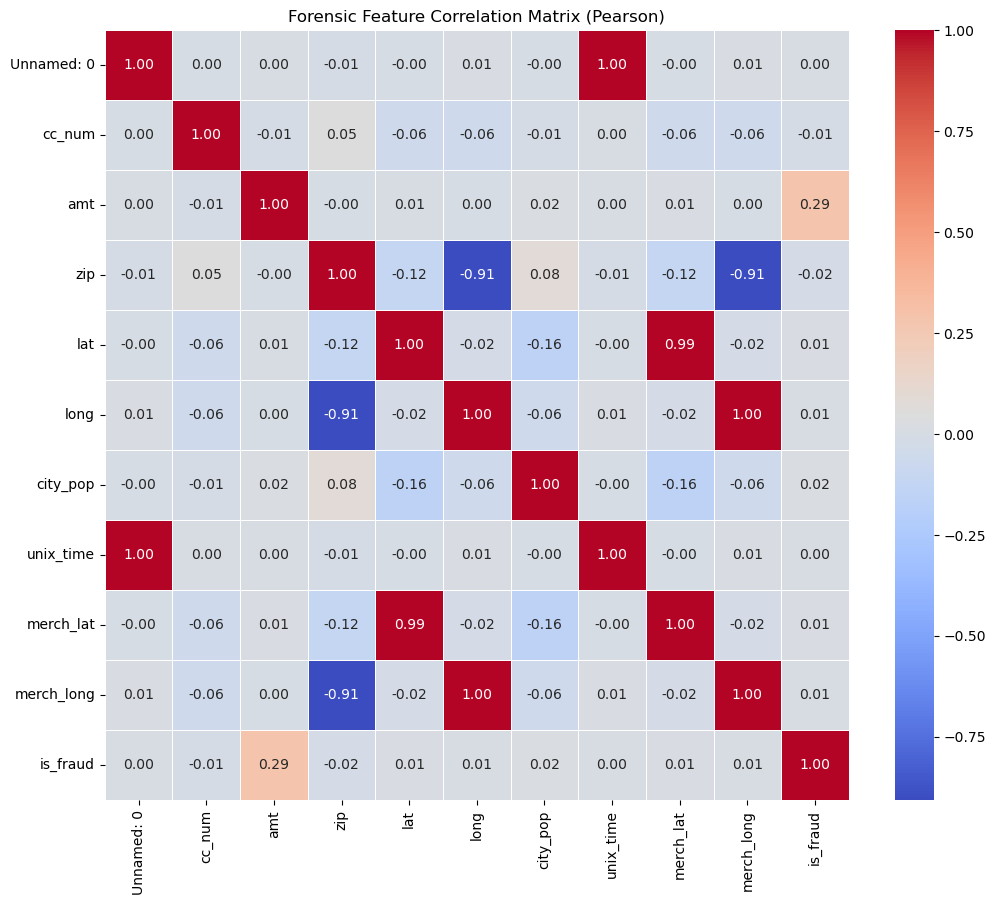

In [6]:
# [EDA] Multivariate: Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_df = df_raw.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Forensic Feature Correlation Matrix (Pearson)")
plt.show()

## 2.  Dimensionality Reduction: Principal Component Analysis (PCA)
Visualizing the variance coverage and forensic separability in a projected 2D space.

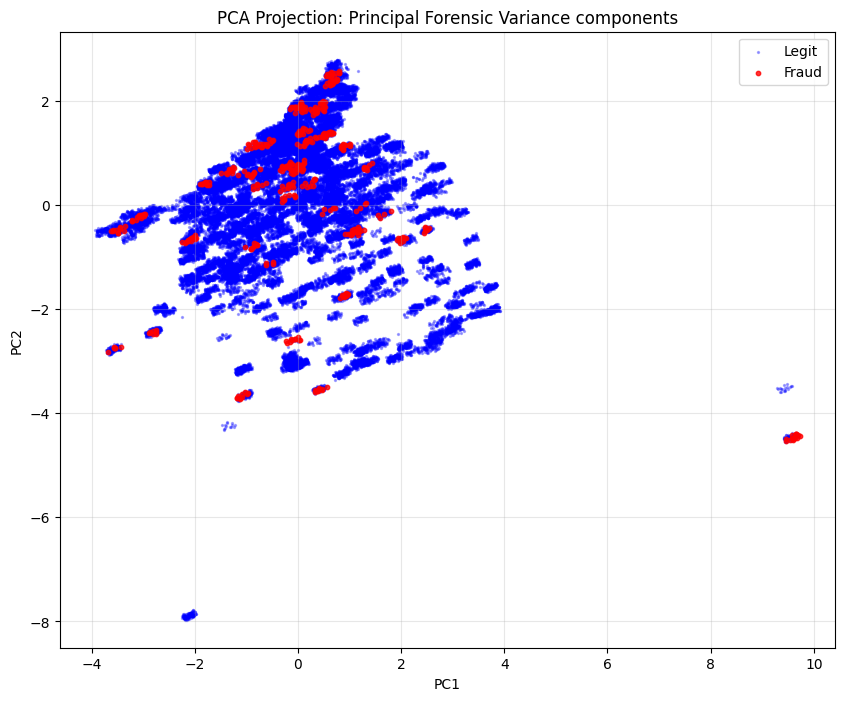

Explained Variance Ratio: 0.5784


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Pre-PCA Preprocessing
X_temp = df_raw[['amt', 'city_pop', 'lat', 'long', 'unix_time', 'merch_lat', 'merch_long']]
y_temp = df_raw['is_fraud']

X_std = StandardScaler().fit_transform(X_temp)
pca = PCA(n_components=2)
components = pca.fit_transform(X_std)

plt.figure(figsize=(10, 8))
plt.scatter(components[y_temp==0, 0], components[y_temp==0, 1], alpha=0.3, label='Legit', c='blue', s=2)
plt.scatter(components[y_temp==1, 0], components[y_temp==1, 1], alpha=0.8, label='Fraud', c='red', s=10)
plt.title("PCA Projection: Principal Forensic Variance components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_.sum():.4f}")

## 3.  High-Fidelity Preprocessing

In [9]:
def engineer(df):
    df['dist'] = np.sqrt((df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2)
    df['date'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['date'].dt.hour
    df['day'] = df['date'].dt.dayofweek
    features = ['category', 'amt', 'city_pop', 'job', 'unix_time', 'dist', 'hour', 'day']
    return df[features], df['is_fraud']

X, y = engineer(df_raw)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

encoder = TargetEncoder()
scaler = RobustScaler()

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)
print("[OK] Preprocessing sequence complete.")

[OK] Preprocessing sequence complete.


## 2.  Metrology: Isolation Forest Pre-Filtering
Eliminating anomalies from the majority class.

In [10]:
iso = IsolationForest(contamination=0.01, random_state=42)
mask_legit = (y_train == 0)
anomalies = iso.fit_predict(X_train_scaled[mask_legit])

X_pure_legit = X_train_scaled[mask_legit][anomalies == 1]
X_fraud = X_train_scaled[y_train == 1]

X_pure = np.vstack([X_pure_legit, X_fraud])
y_pure = np.concatenate([np.zeros(len(X_pure_legit)), np.ones(len(X_fraud))])
print(f"[*] Metrology Filtering: {len(X_train_scaled[mask_legit]) - len(X_pure_legit)} anomalies removed.")

[*] Metrology Filtering: 397 anomalies removed.


## 3.  Competitive Benchmarking

In [11]:
results = {}

# A. Standalone XGBoost
print("[*] Training XGBoost Baseline...")
xgb_standalone = XGBClassifier(n_estimators=100, max_depth=6, eval_metric='aucpr')
xgb_standalone.fit(X_pure, y_pure)
p_xgb = xgb_standalone.predict_proba(X_test_scaled)[:, 1]
results['XGBoost'] = average_precision_score(y_test, p_xgb)

# B. Standalone Balanced Random Forest
print("[*] Training BRF Baseline...")
brf_standalone = BalancedRandomForestClassifier(n_estimators=50, random_state=42)
brf_standalone.fit(X_pure, y_pure)
p_brf = brf_standalone.predict_proba(X_test_scaled)[:, 1]
results['RandomForest'] = average_precision_score(y_test, p_brf)

# C. Hybrid Bayesian Nexus (The Proposed Architecture)
print("[*] Training Hybrid Nexus Ensemble...")
X_s1, X_val, y_s1, y_val = train_test_split(X_pure, y_pure, test_size=0.3, stratify=y_pure)
xgb_h = XGBClassifier(n_estimators=100).fit(X_s1, y_s1)
brf_h = BalancedRandomForestClassifier(n_estimators=50).fit(X_s1, y_s1)

meta_X = np.column_stack((xgb_h.predict_proba(X_val)[:, 1], brf_h.predict_proba(X_val)[:, 1]))
nexus = BayesianRidge().fit(meta_X, y_val)

p_nexus = nexus.predict(np.column_stack((xgb_h.predict_proba(X_test_scaled)[:, 1], brf_h.predict_proba(X_test_scaled)[:, 1])))
results['Hybrid_Nexus'] = average_precision_score(y_test, p_nexus)
print("[OK] Benchmarking suite complete.")

[*] Training XGBoost Baseline...
[*] Training BRF Baseline...
[*] Training Hybrid Nexus Ensemble...
[OK] Benchmarking suite complete.


## 4.  Results Visualization

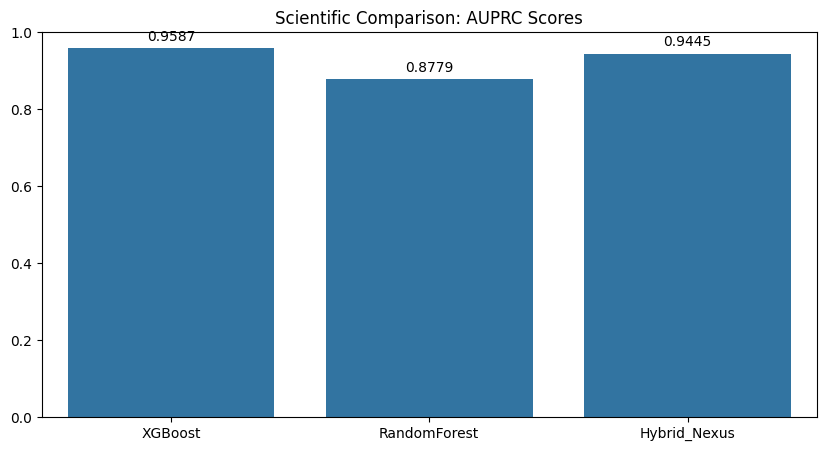


--- FINAL RANKING ---
XGBoost: 0.9587 AUPRC
Hybrid_Nexus: 0.9445 AUPRC
RandomForest: 0.8779 AUPRC


In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Scientific Comparison: AUPRC Scores")
plt.ylim(0, 1)
for i, v in enumerate(results.values()): plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.show()

print("\n--- FINAL RANKING ---")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v:.4f} AUPRC")

## 5. 📦 Production Artifact Export

In [16]:
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
joblib.dump(encoder, os.path.join(MODEL_DIR, "encoder.joblib"))
joblib.dump(xgb_h, os.path.join(MODEL_DIR, "xgb_base.joblib"))
joblib.dump(brf_h, os.path.join(MODEL_DIR, "brf_base.joblib"))
joblib.dump(nexus, os.path.join(MODEL_DIR, "nexus_meta.joblib"))
print(f"[SUCCESS] Production objects exported to {MODEL_DIR}")

[SUCCESS] Production objects exported to c:\Users\REGI GROUP\Documents\Fraud_Detection\research\../app/models/
